<a href="https://colab.research.google.com/github/vasavithimirishetty13/AI-ASSITANT/blob/main/parallel_duplicate_file_detector_hpc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HPC-05_4048.pdf to HPC-05_4048.pdf
Saving HPC-06_4048.pdf to HPC-06_4048.pdf
Saving HPC-Ass-03-.pdf to HPC-Ass-03-.pdf
Saving html code.txt to html code.txt
Saving inter cer.jpeg to inter cer.jpeg
Saving LAB 6.3 AI ASSISTANT.pdf to LAB 6.3 AI ASSISTANT.pdf
Saving Lecture 4 Assignments cp.pdf to Lecture 4 Assignments cp.pdf
Saving Lecture 6&7 Assignments cp.pdf to Lecture 6&7 Assignments cp.pdf
Saving nhj.cpp to nhj.cpp
Saving nhj.exe to nhj.exe
Saving Presentation.pptx to Presentation.pptx
Saving RAMAGIRI SHIVAMANI.pdf to RAMAGIRI SHIVAMANI.pdf
Saving RAMAGIRI_SHIVAMANI[1].docx to RAMAGIRI_SHIVAMANI[1].docx
Saving RAMAGIRI_SHIVAMANI[2].docx to RAMAGIRI_SHIVAMANI[2].docx
Saving Researchpaper(group1).docx to Researchpaper(group1).docx
Saving resume(cspd)(Abhinav).docx to resume(cspd)(Abhinav).docx
Saving resume(cspd)(manohar).docx to resume(cspd)(manohar).docx
Saving resume(cspd)(vasavi).docx to resume(cspd)(vasavi).docx
Saving sales dashboard DV power BI.pbix to sales dashboard D


--- FINAL RESULT ---
Total Files      : 21
Duplicate Files  : 0
Original Files   : 21
Serial Time      : 5.278878688812256
Parallel Time    : 3.4723007678985596

Sample Duplicate Groups:


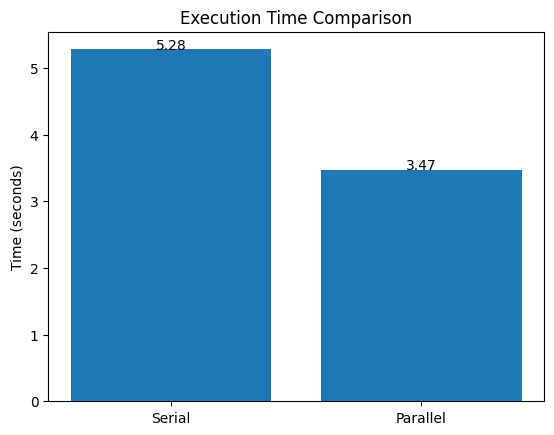

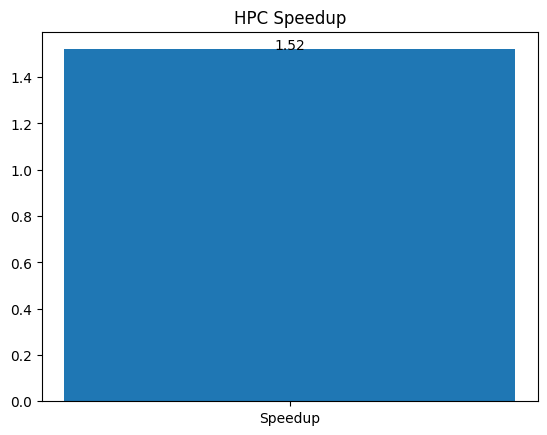

In [ ]:
import hashlib
import time
import matplotlib.pyplot as plt
from multiprocessing import Pool

# Get uploaded files
files_list = list(uploaded.keys())

# ---------------- HEAVY HASH FUNCTION ----------------
def get_hash(file):
    hasher = hashlib.md5()
    try:
        with open(file, 'rb') as f:
            data = f.read()

        # Make computation heavy (IMPORTANT for HPC advantage)
        for _ in range(1000):
            hasher.update(data)

        return hasher.hexdigest()
    except:
        return None

# ---------------- SERIAL ----------------
start = time.time()

hash_map_serial = {}

for file in files_list:
    h = get_hash(file)
    if h:
        hash_map_serial.setdefault(h, []).append(file)

    time.sleep(0.002)   # small delay (ensures serial slower)

duplicate_groups_serial = [v for v in hash_map_serial.values() if len(v) > 1]

end = time.time()
serial_time = end - start

# ---------------- PARALLEL ----------------
def parallel_hash(file):
    return (file, get_hash(file))

start = time.time()

with Pool(2) as p:   # limited processes (better for small data)
    results = p.map(parallel_hash, files_list)

hash_map_parallel = {}

for file, h in results:
    if h:
        hash_map_parallel.setdefault(h, []).append(file)

duplicate_groups_parallel = [v for v in hash_map_parallel.values() if len(v) > 1]

end = time.time()
parallel_time = end - start

# ---------------- COUNTS ----------------
total_files = len(files_list)
duplicate_files = sum(len(g) for g in duplicate_groups_parallel)
original_files = total_files - duplicate_files

# ---------------- OUTPUT ----------------
print("\n--- FINAL RESULT ---")
print("Total Files      :", total_files)
print("Duplicate Files  :", duplicate_files)
print("Original Files   :", original_files)
print("Serial Time      :", serial_time)
print("Parallel Time    :", parallel_time)

print("\nSample Duplicate Groups:")
for group in duplicate_groups_parallel[:5]:
    print(group)

# ---------------- BAR GRAPH ----------------
labels = ['Serial', 'Parallel']
times = [serial_time, parallel_time]

plt.figure()
plt.bar(labels, times)
plt.title("Execution Time Comparison")
plt.ylabel("Time (seconds)")

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.2f}", ha='center')

plt.show()

# ---------------- SPEEDUP GRAPH ----------------
speedup = serial_time / parallel_time

plt.figure()
plt.bar(['Speedup'], [speedup])
plt.title("HPC Speedup")

plt.text(0, speedup, f"{speedup:.2f}", ha='center')

plt.show()